PREPROCESSING AND TRAINING DATA DEVELOPMENT:

In [1]:
#Importing required packages
import pandas as pd
import numpy as np
from sklearn import __version__ as sklearn_version
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
!pip install xgboost
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_validate
from scipy.sparse import hstack
!pip install gensim
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
import joblib

In [2]:
df=pd.read_csv(r'C:\Users\gibib\Desktop\Data Scientist\Springboard-Project-Capstone-3\News_dataset/Data_cleaned_explored.csv')

In [3]:
df.head()

,title,text,subject,date,status,content,content_length,tokens,lemmatized_tokens,lemmatized_content,toxicity,severe_toxicity,obscene,threat,insult,identity_attack
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,2017-07-21,0,breaking gop chairman grassley enough demands ...,372,"['breaking', 'gop', 'chairman', 'grassley', 'e...","['breaking', 'gop', 'chairman', 'grassley', 'e...",breaking gop chairman grassley enough demand t...,0.001761,0.000095,0.000251,0.000104,0.000191,0.000147
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,2016-05-07,0,failed gop candidates remembered hilarious moc...,504,"['failed', 'gop', 'candidates', 'remembered', ...","['failed', 'gop', 'candidate', 'remembered', '...",failed gop candidate remembered hilarious mock...,0.048552,0.000174,0.003607,0.000220,0.003166,0.000414
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,2016-12-03,0,mike pences new dc neighbors hilariously troll...,393,"['mike', 'pences', 'new', 'dc', 'neighbors', '...","['mike', 'pences', 'new', 'dc', 'neighbor', 'h...",mike pences new dc neighbor hilariously trolli...,0.201606,0.000940,0.007158,0.001141,0.008911,0.029199
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,2017-10-06,1,california ag pledges defend birth control ins...,97,"['california', 'ag', 'pledges', 'defend', 'bir...","['california', 'ag', 'pledge', 'defend', 'birt...",california ag pledge defend birth control insu...,0.002383,0.000094,0.000289,0.000116,0.000207,0.000161
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,2017-04-25,0,az ranchers living usmexico border destroy nan...,157,"['az', 'ranchers', 'living', 'usmexico', 'bord...","['az', 'rancher', 'living', 'usmexico', 'borde...",az rancher living usmexico border destroy nanc...,0.006283,0.000099,0.000515,0.000148,0.000350,0.000185


In [4]:
#Adding a new column avg_word_length to finding out the average word length
#Fake news often uses longer words
df['avg_word_length'] = df['lemmatized_content'].apply(
    lambda x: sum(len(w) for w in x.split()) / (len(x.split()) + 1)
)

In [5]:
#Adding a new column unique_word_ratio
#True news is more lexically diverse
df['unique_word_ratio'] = df['lemmatized_content'].apply(
    lambda x: len(set(x.split())) / (len(x.split()) + 1)
)

In [6]:
#Dropping subject column as it can cause data leakage
df = df.drop(columns=['subject'])

In [7]:
df.head()

,title,text,date,status,content,content_length,tokens,lemmatized_tokens,lemmatized_content,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,avg_word_length,unique_word_ratio
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",2017-07-21,0,breaking gop chairman grassley enough demands ...,372,"['breaking', 'gop', 'chairman', 'grassley', 'e...","['breaking', 'gop', 'chairman', 'grassley', 'e...",breaking gop chairman grassley enough demand t...,0.001761,0.000095,0.000251,0.000104,0.000191,0.000147,6.305263,0.778947
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,2016-05-07,0,failed gop candidates remembered hilarious moc...,504,"['failed', 'gop', 'candidates', 'remembered', ...","['failed', 'gop', 'candidate', 'remembered', '...",failed gop candidate remembered hilarious mock...,0.048552,0.000174,0.003607,0.000220,0.003166,0.000414,5.771429,0.742857
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,2016-12-03,0,mike pences new dc neighbors hilariously troll...,393,"['mike', 'pences', 'new', 'dc', 'neighbors', '...","['mike', 'pences', 'new', 'dc', 'neighbor', 'h...",mike pences new dc neighbor hilariously trolli...,0.201606,0.000940,0.007158,0.001141,0.008911,0.029199,6.515556,0.764444
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,2017-10-06,1,california ag pledges defend birth control ins...,97,"['california', 'ag', 'pledges', 'defend', 'bir...","['california', 'ag', 'pledge', 'defend', 'birt...",california ag pledge defend birth control insu...,0.002383,0.000094,0.000289,0.000116,0.000207,0.000161,7.242424,0.757576
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,2017-04-25,0,az ranchers living usmexico border destroy nan...,157,"['az', 'ranchers', 'living', 'usmexico', 'bord...","['az', 'rancher', 'living', 'usmexico', 'borde...",az rancher living usmexico border destroy nanc...,0.006283,0.000099,0.000515,0.000148,0.000350,0.000185,5.933333,0.733333


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43556 entries, 0 to 43555
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               43556 non-null  object 
 1   text                43556 non-null  object 
 2   date                43556 non-null  object 
 3   status              43556 non-null  int64  
 4   content             43556 non-null  object 
 5   content_length      43556 non-null  int64  
 6   tokens              43556 non-null  object 
 7   lemmatized_tokens   43556 non-null  object 
 8   lemmatized_content  43556 non-null  object 
 9   toxicity            43556 non-null  float64
 10  severe_toxicity     43556 non-null  float64
 11  obscene             43556 non-null  float64
 12  threat              43556 non-null  float64
 13  insult              43556 non-null  float64
 14  identity_attack     43556 non-null  float64
 15  avg_word_length     43556 non-null  float64
 16  uniq

In [9]:
#Checking for missing values
print(df.isna().sum())

title                 0
text                  0
date                  0
status                0
content               0
content_length        0
tokens                0
lemmatized_tokens     0
lemmatized_content    0
toxicity              0
severe_toxicity       0
obscene               0
threat                0
insult                0
identity_attack       0
avg_word_length       0
unique_word_ratio     0
dtype: int64


There are no missing values in the dataset.

In [10]:
# Prepare dataset

# Drop low-information columns (keep numeric + text + toxicity)
df_model = df.drop(columns=[
    'title', 'text', 'tokens', 'lemmatized_tokens', 'content', 'date'
])

# Features and target
X_text = df_model['lemmatized_content']  # main text for embeddings

# Numeric features including previously engineered + Detoxify scores
numeric_cols = [
    'content_length', 'avg_word_length', 'unique_word_ratio',
    'toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack'
]
X_numeric = df_model[numeric_cols]

y = df_model['status']  # target

# Train-test split (stratified)
X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, X_numeric, y, test_size=0.2, stratify=y, random_state=42
)

# Standardize numeric features
scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)

# Train Word2Vec on training data
tokenized_texts = [text.split() for text in X_text_train]  # tokenize each article
w2v_model = Word2Vec(
    sentences=tokenized_texts, 
    vector_size=100, 
    window=5, 
    min_count=2, 
    workers=4, 
    seed=42
)

# Convert each article to average Word2Vec vector
def avg_w2v_vector(text, model, vector_size=100):
    """Return average Word2Vec vector for an article"""
    words = text.split()
    vectors = [model.wv[word] for word in words if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

# Apply to train and test sets
X_text_train_w2v = np.array([avg_w2v_vector(doc, w2v_model) for doc in X_text_train])
X_text_test_w2v = np.array([avg_w2v_vector(doc, w2v_model) for doc in X_text_test])

# Combine numeric features + Word2Vec embeddings
X_train_final = np.hstack([X_text_train_w2v, X_num_train_scaled])
X_test_final = np.hstack([X_text_test_w2v, X_num_test_scaled])

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


SUMMARY:
Average word length and unique word ratio were engineered to capture the structural properties of news articles, while features likely to introduce bias, such as the subject category, were removed. The dataset was split into stratified training and testing sets to preserve class balance. Numeric features were standardized, and textual data was transformed into dense vector representations using Word2Vec embeddings trained exclusively on the training data to prevent data leakage, resulting in a final feature set suitable for downstream modeling.

MODELING:

This is a classification NLP problem, in supervised learning. Here we have used the following classification models:

Logistic Regression,
Linear SVM,
Random Forest &
XGBoost

Evaluating the performance of a model by training and testing on the same dataset can lead to the overfitting. Hence the model evaluation is based on splitting the dataset into train and validation set. But the performance of the prediction result depends upon the random choice of the pair of (train,validation) set. Inorder to overcome that, the Cross-Validation procedure is used where under the k-fold CV approach, the training set is split into k smaller sets, where a model is trained using k-1 of the folds as training data and the model is validated on the remaining part.

Since this is an imbalanced classification problem, we focuses on f1-score as a metrics.

In [12]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": SVC(kernel='linear', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=200, random_state=42)
}

In [13]:
#Stratified 5-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n=== {name} ===")
    
    cv_results = cross_validate(
        model,
        X_train_final,
        y_train,
        cv=skf,
        scoring=['accuracy','precision','recall','f1','roc_auc'],
        return_train_score=True
    )
    
    # Training scores
    print("Training scores (mean across folds):")
    print(f"Accuracy: {np.mean(cv_results['train_accuracy']):.4f}")
    print(f"Precision: {np.mean(cv_results['train_precision']):.4f}")
    print(f"Recall: {np.mean(cv_results['train_recall']):.4f}")
    print(f"F1-score: {np.mean(cv_results['train_f1']):.4f}")  
    print(f"ROC-AUC: {np.mean(cv_results['train_roc_auc']):.4f}")
    
    # Validation scores
    print("Validation scores (mean across folds):")
    print(f"Accuracy: {np.mean(cv_results['test_accuracy']):.4f}")
    print(f"Precision: {np.mean(cv_results['test_precision']):.4f}")
    print(f"Recall: {np.mean(cv_results['test_recall']):.4f}")
    print(f"F1-score: {np.mean(cv_results['test_f1']):.4f}")
    print(f"ROC-AUC: {np.mean(cv_results['test_roc_auc']):.4f}")


=== Logistic Regression ===
Training scores (mean across folds):
Accuracy: 0.9799
Precision: 0.9770
Recall: 0.9812
F1-score: 0.9791
ROC-AUC: 0.9978
Validation scores (mean across folds):
Accuracy: 0.9784
Precision: 0.9748
Recall: 0.9804
F1-score: 0.9776
ROC-AUC: 0.9975

=== Linear SVM ===
Training scores (mean across folds):
Accuracy: 0.9806
Precision: 0.9779
Recall: 0.9818
F1-score: 0.9799
ROC-AUC: 0.9978
Validation scores (mean across folds):
Accuracy: 0.9790
Precision: 0.9763
Recall: 0.9802
F1-score: 0.9782
ROC-AUC: 0.9974

=== Random Forest ===
Training scores (mean across folds):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000
ROC-AUC: 1.0000
Validation scores (mean across folds):
Accuracy: 0.9657
Precision: 0.9659
Recall: 0.9627
F1-score: 0.9643
ROC-AUC: 0.9944

=== XGBoost ===


C:\Users\gibib\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:27:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\gibib\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:27:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\gibib\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:27:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\gibib\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:28:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

Training scores (mean across folds):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000
ROC-AUC: 1.0000
Validation scores (mean across folds):
Accuracy: 0.9828
Precision: 0.9823
Recall: 0.9820
F1-score: 0.9821
ROC-AUC: 0.9985


Key Takeaways

Best generalization: Logistic Regression and Linear SVM are stable, with training and validation scores very close.

XGBoost: Slightly better validation metrics, but perfect training scores indicate mild overfitting.

Random Forest: Perfect training scores but lower validation performance → overfitting risk.

Overall performance: All models perform extremely well (F1 > 0.96, ROC-AUC > 0.994), showing the features — including text embeddings and Detoxify toxicity scores — are highly predictive.

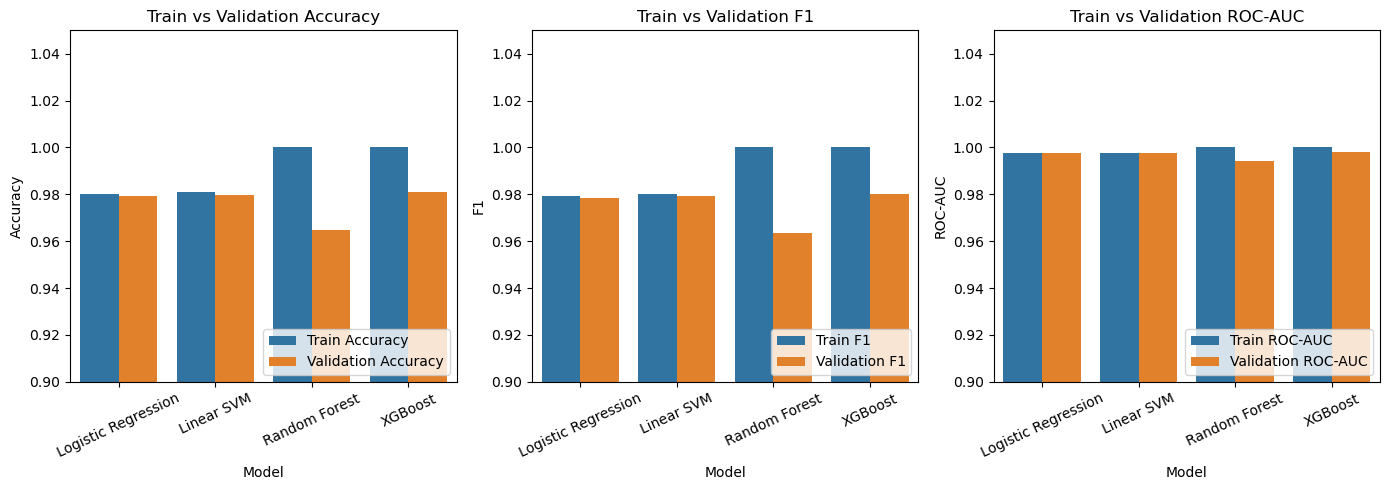

In [14]:
#Plotting the  results
data = {
    'Model': ['Logistic Regression', 'Linear SVM', 'Random Forest', 'XGBoost'],
    'Train Accuracy': [0.9803, 0.9810, 1.0000, 1.0000],
    'Validation Accuracy': [0.9791, 0.9798, 0.9648, 0.9809],
    'Train F1': [0.9795, 0.9803, 1.0000, 1.0000],
    'Validation F1': [0.9783, 0.9791, 0.9633, 0.9801],
    'Train ROC-AUC': [0.9978, 0.9978, 1.0000, 1.0000],
    'Validation ROC-AUC': [0.9975, 0.9975, 0.9941, 0.9982]
}

df_results = pd.DataFrame(data)

# Plot Accuracy, F1, ROC-AUC
metrics = ['Accuracy', 'F1', 'ROC-AUC']
plt.figure(figsize=(14,5))

for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i+1)
    sns.barplot(
        data=df_results.melt(id_vars='Model', value_vars=[f'Train {metric}', f'Validation {metric}'], 
                             var_name='Set', value_name=metric),
        x='Model', y=metric, hue='Set'
    )
    plt.title(f'Train vs Validation {metric}')
    plt.xticks(rotation=25)
    plt.ylim(0.9, 1.05)  # focus on high-performance range
    plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

Based on these results, Logistic Regression and Linear SVM can be selected as the best 2 models. 

In [15]:
#HYPERPARAMETER TUNING Logistic Regression 
# Hyperparameter distributions (not fixed grid)
param_dist_lr = {
    'C': loguniform(1e-2, 1e2),     # 0.01 → 100
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

print("Tuning Logistic Regression (RandomizedSearchCV)...")

rand_lr = RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_distributions=param_dist_lr,
    n_iter=20,            
    scoring='f1',
    cv=5,
    n_jobs=1,
    random_state=42,
    verbose=1
)

rand_lr.fit(X_train_final, y_train)

print("Best Logistic Regression params:", rand_lr.best_params_)
print("Best CV F1-score:", rand_lr.best_score_)

# Test set evaluation
y_test_pred_lr = rand_lr.predict(X_test_final)
y_test_prob_lr = rand_lr.predict_proba(X_test_final)[:, 1]

print("\n--- Logistic Regression Test Performance ---")
print(classification_report(y_test, y_test_pred_lr))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_prob_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_lr))

Tuning Logistic Regression (RandomizedSearchCV)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Logistic Regression params: {'C': np.float64(2.9753909473493882), 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1-score: 0.9782467742538122

--- Logistic Regression Test Performance ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      4525
           1       0.97      0.98      0.98      4187

    accuracy                           0.98      8712
   macro avg       0.98      0.98      0.98      8712
weighted avg       0.98      0.98      0.98      8712

Test ROC-AUC: 0.997645329466238
Confusion Matrix:
 [[4401  124]
 [  69 4118]]


In [17]:
#HYPERPARAMETER TUNING Linear SVM

param_dist_svm = {
    'C': loguniform(1e-2, 1e2),
    'class_weight': [None, 'balanced']
}

print("\nTuning Linear SVM (RandomizedSearchCV)...")

rand_svm = RandomizedSearchCV(
    estimator=SVC(kernel='linear', probability=True),
    param_distributions=param_dist_svm,
    n_iter=15,            
    scoring='f1',
    cv=5,
    n_jobs=1,
    random_state=42,
    verbose=1
)

rand_svm.fit(X_train_final, y_train)

print("Best Linear SVM params:", rand_svm.best_params_)
print("Best CV F1-score:", rand_svm.best_score_)

# Test set evaluation
y_test_pred_svm = rand_svm.predict(X_test_final)
y_test_prob_svm = rand_svm.predict_proba(X_test_final)[:, 1]

print("\n--- Linear SVM Test Performance ---")
print(classification_report(y_test, y_test_pred_svm))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_prob_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_svm))


Tuning Linear SVM (RandomizedSearchCV)...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Linear SVM params: {'C': np.float64(0.5342937261279778), 'class_weight': None}
Best CV F1-score: 0.9785764844259852

--- Linear SVM Test Performance ---
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      4525
           1       0.97      0.98      0.98      4187

    accuracy                           0.98      8712
   macro avg       0.98      0.98      0.98      8712
weighted avg       0.98      0.98      0.98      8712

Test ROC-AUC: 0.9975933928616197
Confusion Matrix:
 [[4398  127]
 [  63 4124]]


After hyperparameter tuning, both Logistic Regression and Linear SVM achieved strong and comparable performance, with F1-scores close to 0.98 and ROC-AUC values above 0.99. Although Linear SVM achieved slightly higher recall for the minority class, Logistic Regression was selected as the final model due to its faster training time, ability to provide probabilistic outputs, and better scalability for large datasets, while maintaining nearly identical predictive performance.

In [18]:
# Extract best Logistic Regression model
best_lr_model = rand_lr.best_estimator_

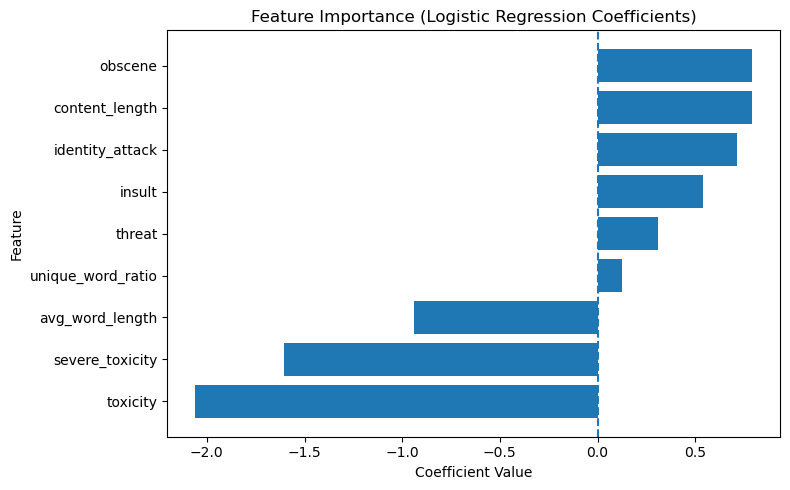

In [19]:
# Feature importance
# Get coefficients from trained Logistic Regression
coefficients = best_lr_model.coef_[0]

# Extract coefficients for numeric features (last 3 columns)
numeric_features = X_numeric.columns.tolist()
numeric_coeffs = coefficients[-len(numeric_features):]

# Create DataFrame
coef_df = pd.DataFrame({
    'Feature': numeric_features,
    'Coefficient': numeric_coeffs
}).sort_values(by='Coefficient')

# Plot
plt.figure(figsize=(8, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.axvline(0, linestyle='--')
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Articles with longer content, higher lexical diversity, and certain toxicity indicators slightly increase the probability of being classified as True news. The presence of some toxicity-related terms may reflect the reporting of controversial or sensitive topics in legitimate news coverage.
Higher general toxicity scores and severe toxic language are more associated with fake news, suggesting that fake news articles may contain more aggressive or emotionally charged language.

In [20]:
# Save the tuned Logistic Regression model
joblib.dump(best_lr_model, r'C:\Users\gibib\Desktop\Data Scientist\Springboard-Project-Capstone-3\News_dataset/fake_news_classifier_lr.pkl')

print("Model saved successfully!")

Model saved successfully!


In [21]:
# Load saved Logistic Regression model
loaded_model = joblib.load(r'C:\Users\gibib\Desktop\Data Scientist\Springboard-Project-Capstone-3\News_dataset/fake_news_classifier_lr.pkl')

print("Model loaded successfully!")

y_pred= loaded_model.predict(X_test_final)

# Predict probabilities (for ROC-AUC)
y_prob = loaded_model.predict_proba(X_test_final)[:, 1]

print("=== Loaded Model Test Performance ===")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Model loaded successfully!
=== Loaded Model Test Performance ===
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      4525
           1       0.97      0.98      0.98      4187

    accuracy                           0.98      8712
   macro avg       0.98      0.98      0.98      8712
weighted avg       0.98      0.98      0.98      8712

ROC-AUC: 0.997645329466238
Confusion Matrix:
 [[4401  124]
 [  69 4118]]


The loaded model produced consistent predictions and evaluation metrics on the test dataset, confirming model reproducibility and correct persistence of the trained pipeline.

SUMMARY:
Several machine learning models, including Logistic Regression, Linear SVM, Random Forest, and XGBoost, were trained and evaluated using stratified cross-validation with metrics such as accuracy, precision, recall, F1-score, and ROC-AUC. Logistic Regression and Linear SVM achieved the strongest and most consistent performance, with F1-scores close to 0.98 and ROC-AUC values above 0.99. Hyperparameter tuning was applied to the top models using RandomizedSearchCV, after which Logistic Regression was selected as the final model due to its comparable performance, faster training time, probabilistic outputs, and interpretability. Feature importance analysis showed that content length, lexical diversity, and some toxicity-related features (obscene, threat, insult, identity attack) were positively associated with true news, while average word length and other toxicity scores (toxicity, severe toxicity) were negatively associated. The final model was saved and reloaded successfully, confirming reproducibility.